### Results
The simple linear model functions well on the random samples which are scored high but absolutely fails on the artifficial samples that should be labeled as anomalous

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch 

In [ ]:
from anomaly_detection.utils.load_sam_data import load_dataset
from anomaly_detection.utils.preprocess import drop_empty_histograms
from anomaly_detection.utils.preprocess import minmax_scale_per_sample
from anomaly_detection.utils.plotting_styles import apply_global_style

dataset = load_dataset("FJ")
full_dataset = np.array(dataset)
full_dataset = minmax_scale_per_sample(full_dataset)

dataset_no_outs = drop_empty_histograms(full_dataset)

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\FJ\FI01X1\FI01X1_ch
Dropped indexes [8, 15, 188, 214, 263, 268, 533, 546]


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(dataset_no_outs, shuffle=True, train_size=0.8, random_state=42)

In [9]:
dataset_no_outs = torch.from_numpy(dataset_no_outs)
X_train = torch.from_numpy(X_train)
X_test = torch.from_numpy(X_test)
full_dataset = torch.from_numpy(full_dataset)

dataset_no_outs = dataset_no_outs.to(torch.float32)
X_train = X_train.to(torch.float32)
X_test = X_test.to(torch.float32)
full_dataset = full_dataset.to(torch.float32)

In [10]:
from anomaly_detection.config.paths import CHECKPOINT_DIR
from anomaly_detection.models.lin_ae import LinAutoencoder

checkpoint = torch.load(f"{CHECKPOINT_DIR}/lin_autoenc_v1.pth", map_location="cpu")

config = checkpoint["config"]

model = LinAutoencoder()
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

LinAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=96, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): Sigmoid()
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=96, bias=True)
    (5): Sigmoid()
  )
)

In [12]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Model consists of", trainable_params, "trainable parameters.")

Model consists of 17712 trainable parameters.


In [13]:
from anomaly_detection.utils.test_and_eval import get_outliers

outs = get_outliers(full_dataset)

In [14]:
def score_points(pts, criterion=None):
    if not criterion:
        import torch
        criterion = torch.nn.MSELoss()

    out_scores = []
    for out in pts:
        pred = model(out).detach()
        loss = criterion(pred, out).detach().numpy()
        out_scores.append(loss)
        
    return out_scores

In [15]:
import torch.nn as nn

criterion = nn.MSELoss()
scores = score_points(full_dataset, criterion)

In [16]:
out_scores = score_points(outs, criterion)

In [24]:
import pandas as pd 
from anomaly_detection.config.paths import DATA_DIR
import os

eval_df = pd.read_parquet(os.path.join(DATA_DIR, 'eval_data', 'eval_dataset.parquet'))

In [ ]:
eval_df[eval_df['category'] == 'strong']['histogram'].values

<>:1: SyntaxWarning: str indices must be integers or slices, not str; perhaps you missed a comma?
<>:1: SyntaxWarning: str indices must be integers or slices, not str; perhaps you missed a comma?
C:\Users\hrdyj\AppData\Local\Temp\ipykernel_28968\3655038098.py:1: SyntaxWarning: str indices must be integers or slices, not str; perhaps you missed a comma?
  eval_df['category'] == 'strong'['histogram'].values


TypeError: string indices must be integers, not 'str'

In [ ]:
eval_score = score_points(torch.tensor(eval_df['histogram']).to(torch.float32))

RuntimeError: both arguments to linear need to be at least 1D, but they are 0D and 2D

In [75]:
eval_df

,histogram,category
0,"[0.567523717880249, 0.09575086832046509, 0.520...",random
1,"[0.31962132453918457, 0.9295916557312012, 0.10...",random
2,"[0.07338769733905792, 0.08005930483341217, 0.0...",strong
3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",strong
4,"[0.07338769733905792, 0.08005930483341217, 0.0...",medium
5,"[0.07338769733905792, 0.08005930483341217, 0.0...",medium
6,"[0.07338769733905792, 0.08005930483341217, 0.0...",weak
7,"[1.0, 1.0, 1.0, 1.0, 1.0, 0.12750186026096344,...",weak
8,"[0.07511565089225769, 0.10194530338048935, 0.0...",normal
9,"[0.018223686143755913, 0.021402651444077492, 0...",normal


In [ ]:
eval_score = score_points(eval_df['histogram'])

[array(0.17419618, dtype=float32),
 array(0.18118566, dtype=float32),
 array(0.2466232, dtype=float32),
 array(0.09143893, dtype=float32),
 array(0.08242434, dtype=float32),
 array(0.17776291, dtype=float32),
 array(0.02357624, dtype=float32),
 array(0.05487235, dtype=float32),
 array(0.00845925, dtype=float32),
 array(0.01717274, dtype=float32)]

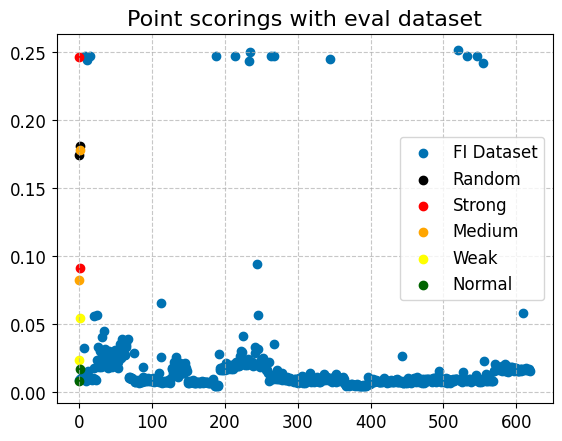

In [84]:
apply_global_style()
plt.title("Point scorings with eval dataset")
plt.scatter(range(len(scores)), scores, label='FI Dataset')
plt.scatter(range(len(eval_score[:2])), eval_score[:2], color='black', label='Random')
plt.scatter(range(len(eval_score[2:4])), eval_score[2:4], color='red', label='Strong')
plt.scatter(range(len(eval_score[4:6])), eval_score[4:6], color='orange', label='Medium')
plt.scatter(range(len(eval_score[6:8])), eval_score[6:8], color='yellow', label='Weak')
plt.scatter(range(len(eval_score[8:])), eval_score[8:], color='darkgreen', label='Normal')
plt.legend()

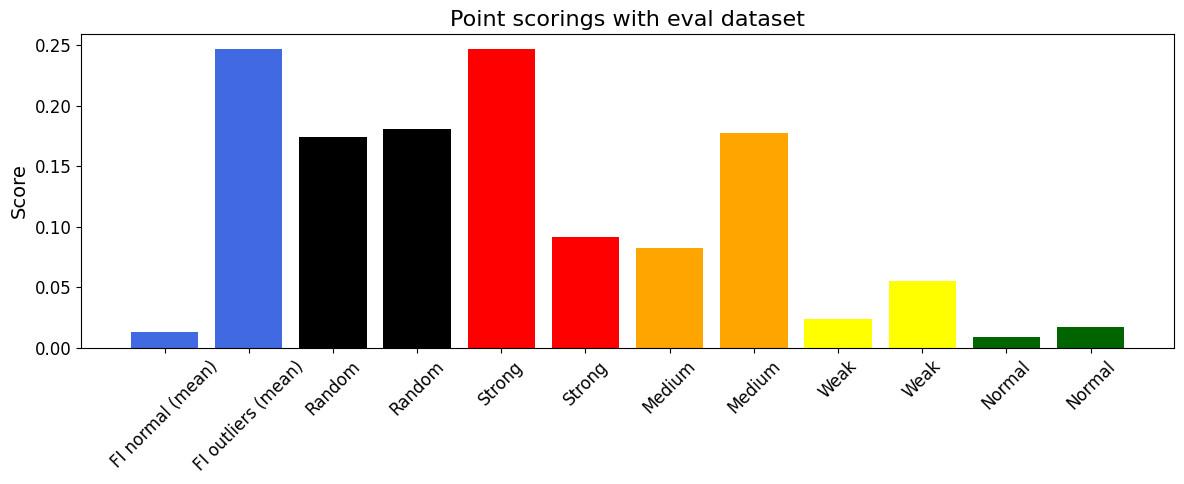

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

scores = np.array(scores)
eval_score = np.array(eval_score)

fi_above = scores[scores > 0.2]
fi_below = scores[scores <= 0.2]

fi_above_mean = fi_above.mean() if len(fi_above) else 0
fi_below_mean = fi_below.mean() if len(fi_below) else 0

values = [fi_below_mean, fi_above_mean]
colors = ["royalblue", "royalblue"]
labels = ["FI normal (mean)", "FI outliers (mean)"]

group_colors = ["black", "red", "orange", "yellow", "darkgreen"]
group_labels = ["Random", "Strong", "Medium", "Weak", "Normal"]

for i in range(0, len(eval_score), 2):
    pair = eval_score[i:i+2]
    group_idx = i // 2
    
    for val in pair:
        values.append(val)
        colors.append(group_colors[group_idx])
        labels.append(group_labels[group_idx])

plt.figure(figsize=(12, 5))
plt.title("Point scorings with eval dataset")

x = np.arange(len(values))
plt.bar(x, values, color=colors)

plt.xticks(x, labels, rotation=45)
plt.ylabel("Score")

plt.tight_layout()
plt.show()